# Stock Forecasting — Lag-Feature Attention vs Baselines

Walk-forward evaluation of Ridge and Attention models across S&P 500 sector ETFs.
All models share identical data, feature construction, and evaluation logic.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "..")

from src.data.loader import download_prices, format_prices, get_ticker_data
from src.models.ridge import RidgeForecaster
from src.models.attention import AttentionForecaster
from src.evaluation.walk_forward import walk_forward, run_evaluation

sns.set_style("whitegrid")
SEED = 40304451
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

## Shared Config

All tickers, dates, and evaluation parameters are declared once here.
Both models use identical inputs to ensure a fair comparison.

In [2]:
TICKERS = [
    "XLK",   # Technology
    "XLP",   # Consumer Staples
    "XLV",   # Health Care
    "XLF",   # Financials
    "XLE",   # Energy
    "XLI",   # Industrials
    "XLY",   # Consumer Discretionary
    "XLU",   # Utilities
    "XLB",   # Materials
    "XLRE",  # Real Estate
    "XLC",   # Communication Services
]

DATE_DOWNLOAD_START = "2010-01-01"
DATE_DOWNLOAD_END   = "2024-12-31"
DATE_EVAL_START     = "2015-01-01"
DATE_EVAL_END       = "2019-12-31"

HORIZON = 5
N_LAGS = 20
STEP = 10

print(f"Tickers: {TICKERS}")
print(f"Download: {DATE_DOWNLOAD_START} to {DATE_DOWNLOAD_END}")
print(f"Eval: {DATE_EVAL_START} to {DATE_EVAL_END}")
print(f"Horizon: {HORIZON} days | Lags: {N_LAGS} | Step: {STEP} days")

Tickers: ['XLK', 'XLP', 'XLV', 'XLF', 'XLE', 'XLI', 'XLY', 'XLU', 'XLB', 'XLRE', 'XLC']
Download: 2010-01-01 to 2024-12-31
Eval: 2015-01-01 to 2019-12-31
Horizon: 5 days | Lags: 20 | Step: 10 days


## Feature Configs

Feature configs control what `build_features` constructs.
Both models receive the same (X, y, dates) for a given feature config.

In [3]:
FEATURE_CONFIGS = {
    "lags_only": {
        "n_lags": N_LAGS,
        "parkinson_vol_windows": (),
    },
    "lags_and_pvol": {
        "n_lags": N_LAGS,
        "parkinson_vol_windows": (5, 10),
    },
}

print(f"Feature configs: {list(FEATURE_CONFIGS.keys())}")

Feature configs: ['lags_only', 'lags_and_pvol']


## Model Configs

We control our model hyperparameters through model configs.

In [4]:
RIDGE_CONFIG = {
    "alpha_grid": (0.01, 0.1, 1.0, 10.0, 100.0, 1000.0),
    "cv_splits": 3,
}

ATTENTION_CONFIG = {
    "embed_dim": 32,
    "num_queries": 4,
    "batch_size": 32,
    "max_epochs": 100,
    "patience": 10,
    "learning_rate": 1e-3,
    "grad_clip": 1.0,
}

# It's then easy to load our models like so
MODELS = {
    "ridge": (RidgeForecaster, RIDGE_CONFIG),
    "attention": (AttentionForecaster, ATTENTION_CONFIG),
}

print(f"Models: {list(MODELS.keys())}")

Models: ['ridge', 'attention']


## Download Data

In [5]:
raw_prices = download_prices(TICKERS, start=DATE_DOWNLOAD_START, end=DATE_DOWNLOAD_END)
prices_df = format_prices(raw_prices)

print(f"DataFrame shape: {prices_df.shape}")
print(f"Tickers present: {prices_df['ticker'].unique().tolist()}")
prices_df.head()

XLK: 3773 rows downloaded
XLP: 3773 rows downloaded
XLV: 3773 rows downloaded
XLF: 3773 rows downloaded
XLE: 3773 rows downloaded
XLI: 3773 rows downloaded
XLY: 3773 rows downloaded
XLU: 3773 rows downloaded
XLB: 3773 rows downloaded
XLRE: 2322 rows downloaded
XLC: 1644 rows downloaded

Total rows before cleaning: 37923

Missing values per column after formatting:
Open      0
High      0
Low       0
Close     0
Volume    5
dtype: int64
DataFrame shape: (37923, 10)
Tickers present: ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains,ticker
date,,,,,,,,,,
2010-01-04,16.790001,17.010000,16.725000,17.010000,12.016514,15135000.0,0.0,0.0,0.0,XLB
2010-01-05,17.040001,17.090000,16.905001,17.065001,12.055369,17678400.0,0.0,0.0,0.0,XLB
2010-01-06,17.070000,17.415001,17.040001,17.355000,12.260233,16184000.0,0.0,0.0,0.0,XLB
2010-01-07,17.270000,17.290001,17.080000,17.219999,12.164866,11514600.0,0.0,0.0,0.0,XLB
2010-01-08,17.180000,17.459999,17.139999,17.459999,12.334406,9284800.0,0.0,0.0,0.0,XLB


## Walk-Forward Experiment Loop

Iterates over tickers x feature configs x models.
Each combination is evaluated independently on the same walk-forward splits.

In [ ]:
results = {}

for ticker in TICKERS:
    print(f"\n{'='*60}")
    print(f"Ticker: {ticker}")
    print(f"{'='*60}")

    prices = get_ticker_data(prices_df, ticker)

    for feature_config_name, feature_config in FEATURE_CONFIGS.items():
        print(f"\nFeature config: {feature_config_name}")

        for model_name, (forecaster_cls, model_config) in MODELS.items():
            print(f"Model: {model_name}/n-------------------")

            combined_config = {**feature_config, **model_config}

            forecaster = forecaster_cls(combined_config)
            X, y, dates = forecaster.build_features(prices, horizon=HORIZON)

            fold_results = walk_forward(
                X=X,
                y=y,
                dates=dates,
                forecaster_cls=forecaster_cls,
                config=combined_config,
                eval_start=DATE_EVAL_START,
                eval_end=DATE_EVAL_END,
                horizon=HORIZON,
                step=STEP,
            )

            metrics = run_evaluation(fold_results)
            metrics["ticker"] = ticker
            metrics["feature_config"] = feature_config_name
            metrics["model"] = model_name

            key = f"{ticker}_{feature_config_name}_{model_name}"
            results[key] = metrics

            print(f"  IC={metrics['ic']:.4f} | DirAcc={metrics['diracc']:.4f} | MAE={metrics['mae']:.6f}")


Ticker: XLK
XLK: 3773 rows, 2010-01-04 to 2024-12-30

Feature config: lags_only
Model: ridge/n-------------------


RidgeForecaster | n_lags=20, pvol_windows=()
build_features | horizon=5
_make_features | shape=(3752, 20), columns=['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ret_lag6', 'ret_lag7', 'ret_lag8', 'ret_lag9', 'ret_lag10', 'ret_lag11', 'ret_lag12', 'ret_lag13', 'ret_lag14', 'ret_lag15', 'ret_lag16', 'ret_lag17', 'ret_lag18', 'ret_lag19', 'ret_lag20']
build_features | X=(3747, 20, 1), y=(3747,)
  date range: 2010-02-03 to 2024-12-20
  y mean=0.003234, std=0.027370
fold 1 | train=1237, test=10, first_test=2015-01-02


RidgeForecaster | n_lags=20, pvol_windows=()
----alpha=0.01 | avg_mse=0.000481
----alpha=0.1 | avg_mse=0.000481
----alpha=1.0 | avg_mse=0.000481
----alpha=10.0 | avg_mse=0.000481
----alpha=100.0 | avg_mse=0.000479
----alpha=1000.0 | avg_mse=0.000479
best_alpha=1000.0 | best_mse=0.000479
y_pred mean=0.004387, std=0.001894
fold 2 | train=1247, tes

## Results

In [ ]:
results_df = pd.DataFrame(results).T.reset_index(drop=True)
results_df = results_df[["ticker", "feature_config", "model", "ic", "diracc", "mae", "rmse"]]
results_df[["ic", "diracc", "mae", "rmse"]] = (
    results_df[["ic", "diracc", "mae", "rmse"]].astype(float).round(4)
)

results_df.to_csv("../results/notebook/01_experiment_results.csv", index=False)
print(results_df.to_string(index=False))

ticker feature_config     model      ic  diracc    mae   rmse
   XLK      lags_only     ridge  0.0378  0.5874 0.0169 0.0228
   XLK      lags_only attention  0.0721  0.5668 0.0172 0.0234
   XLK  lags_and_pvol     ridge  0.0122  0.5747 0.0171 0.0231
   XLK  lags_and_pvol attention  0.0360  0.5103 0.0183 0.0248
   XLP      lags_only     ridge -0.0036  0.5628 0.0116 0.0161
   XLP      lags_only attention -0.0055  0.5000 0.0121 0.0165
   XLP  lags_and_pvol     ridge  0.0078  0.5517 0.0117 0.0161
   XLP  lags_and_pvol attention -0.0346  0.4674 0.0130 0.0177
   XLV      lags_only     ridge  0.0235  0.5676 0.0153 0.0206
   XLV      lags_only attention  0.0338  0.5421 0.0165 0.0221
   XLV  lags_and_pvol     ridge -0.0684  0.5596 0.0155 0.0208
   XLV  lags_and_pvol attention -0.0014  0.5103 0.0170 0.0229
   XLF      lags_only     ridge  0.0173  0.5310 0.0172 0.0237
   XLF      lags_only attention  0.0119  0.5167 0.0181 0.0249
   XLF  lags_and_pvol     ridge -0.0121  0.5286 0.0174 0.0240
   XLF  

In [ ]:
summary = (
    results_df
    .groupby(["model", "feature_config"])[["ic", "diracc", "mae", "rmse"]]
    .mean()
    .round(4)
)
print("Mean metrics across all tickers:")
print(summary.to_string())

Mean metrics across all tickers:
                              ic  diracc     mae    rmse
model     feature_config                                
attention lags_and_pvol   0.0121  0.5029  0.0185  0.0259
          lags_only       0.0384  0.5287  0.0174  0.0234
ridge     lags_and_pvol  -0.0024  0.5288  0.0165  0.0222
          lags_only       0.0105  0.5368  0.0164  0.0221


## IC Comparison — Ridge vs Attention

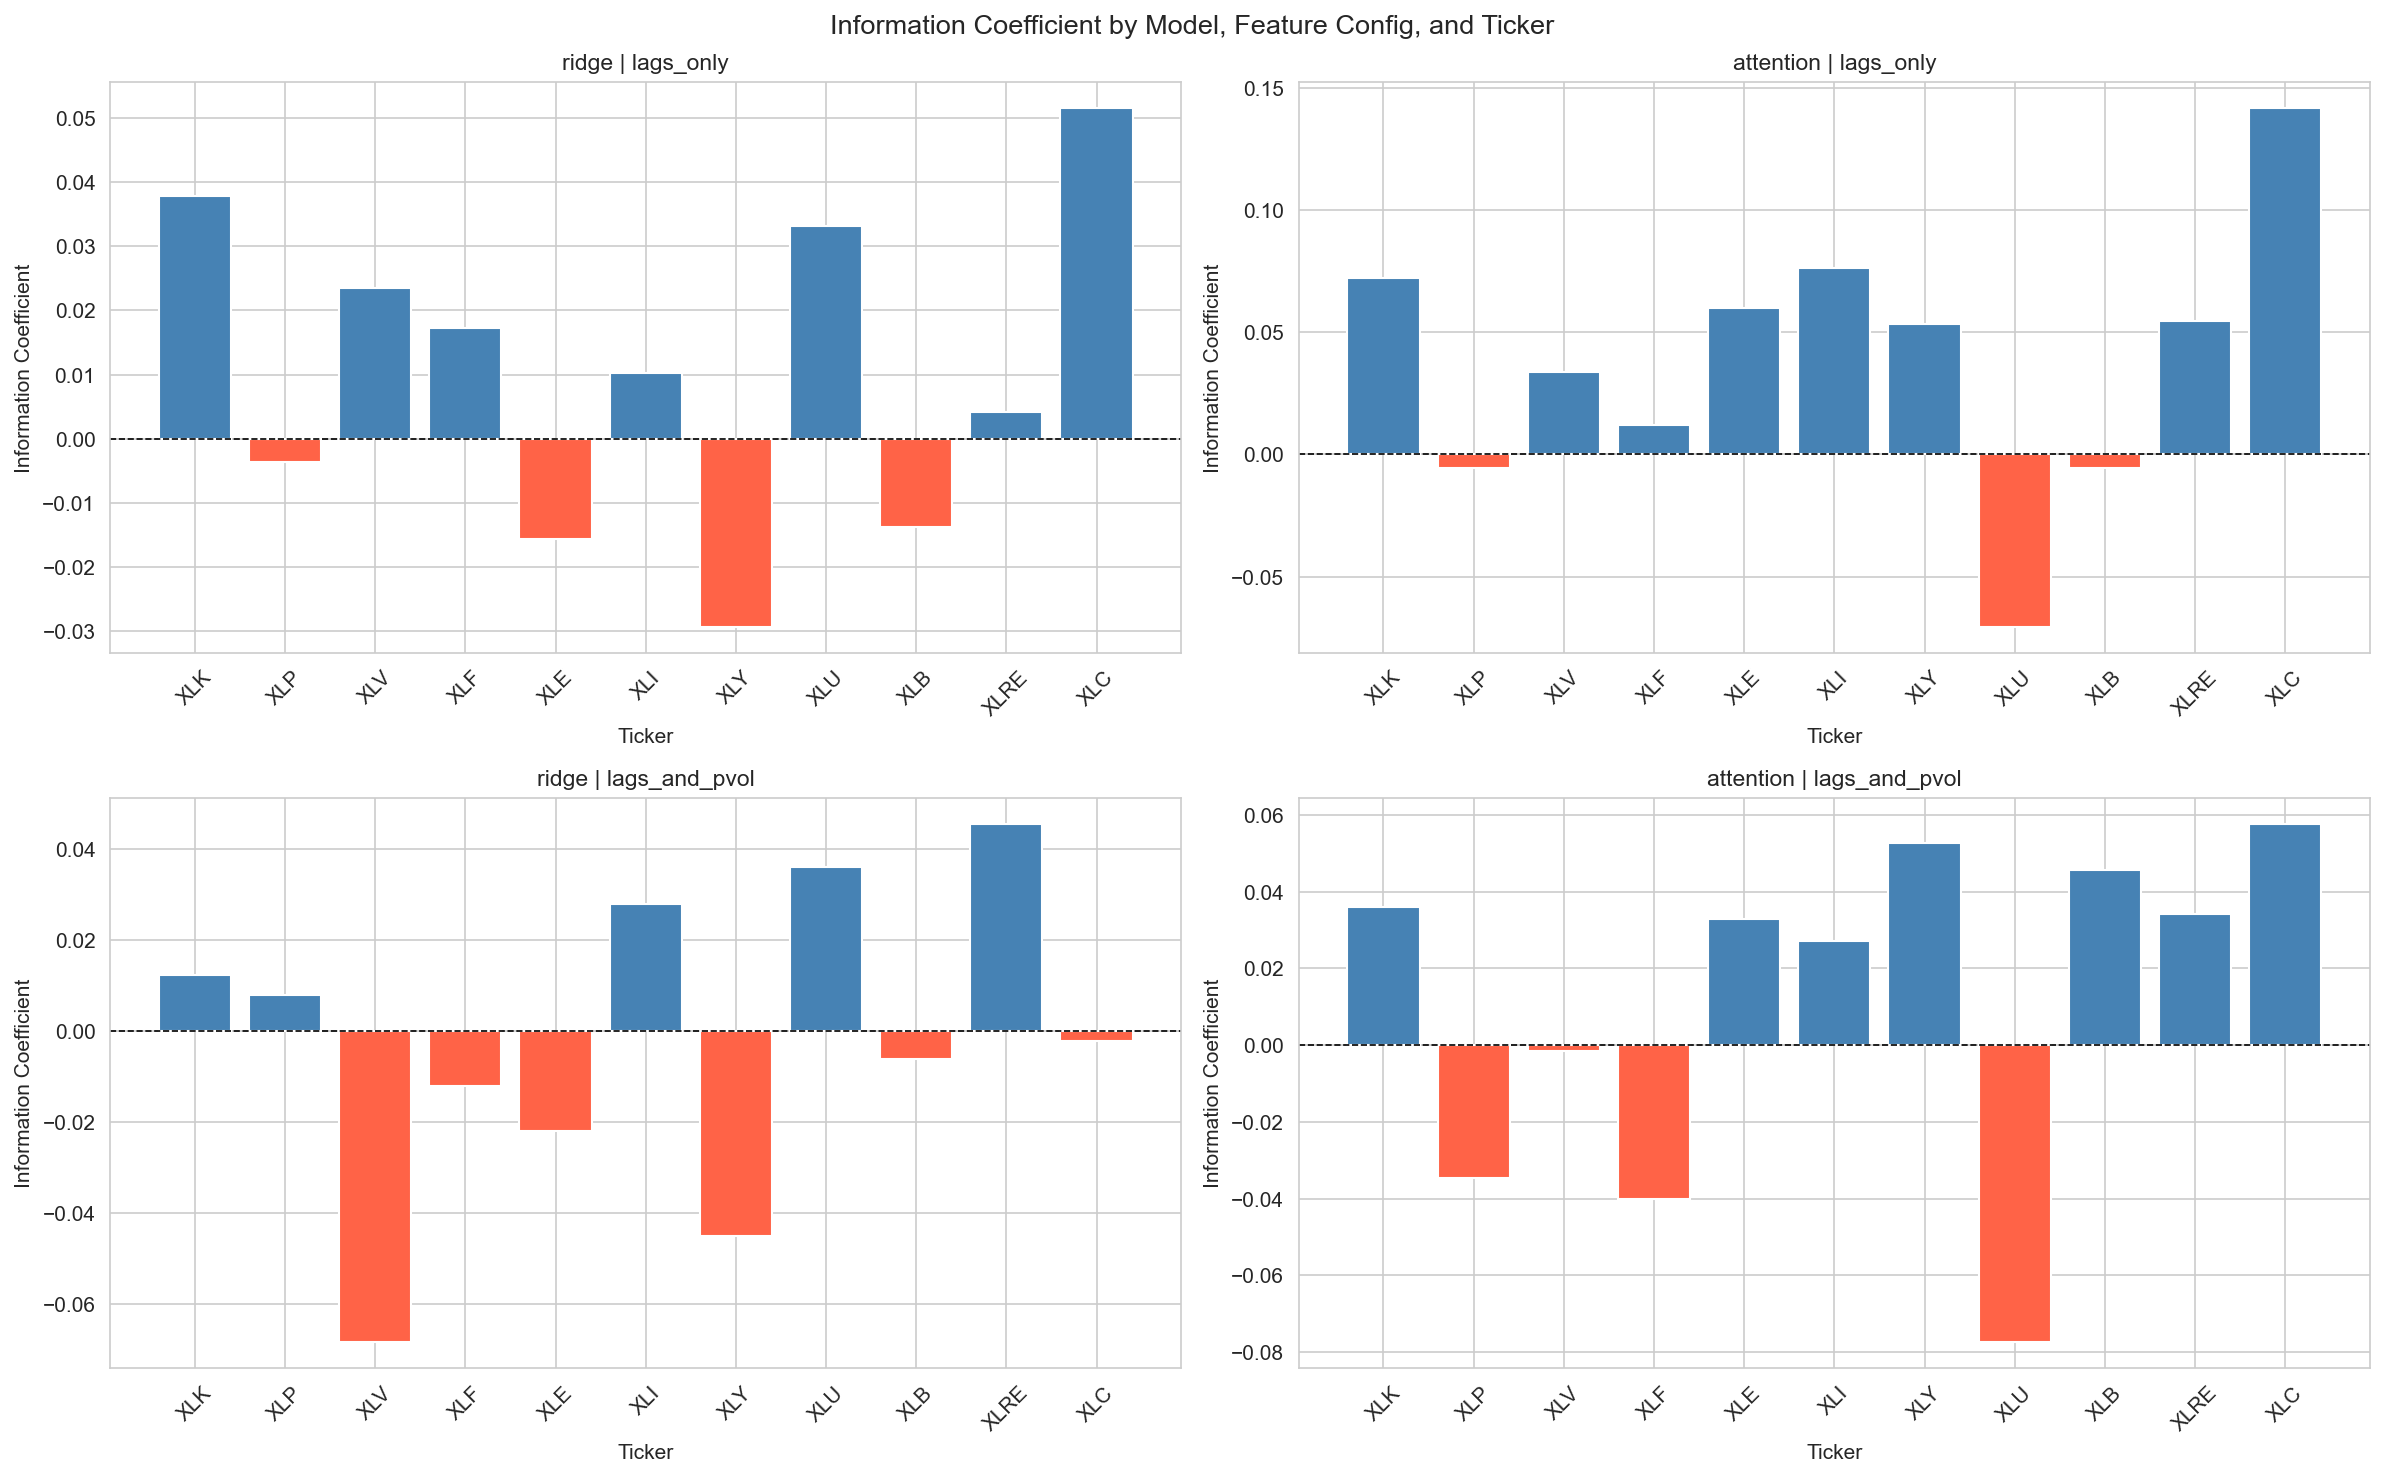

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

for row_idx, feature_config_name in enumerate(FEATURE_CONFIGS.keys()):
    for col_idx, model_name in enumerate(MODELS.keys()):
        ax = axes[row_idx][col_idx]
        subset = results_df[
            (results_df["feature_config"] == feature_config_name) &
            (results_df["model"] == model_name)
        ].copy()

        colours = ["steelblue" if v >= 0 else "tomato" for v in subset["ic"]]
        ax.bar(subset["ticker"], subset["ic"], color=colours)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{model_name} | {feature_config_name}", fontsize=11)
        ax.set_xlabel("Ticker")
        ax.set_ylabel("Information Coefficient")
        ax.tick_params(axis="x", rotation=45)

plt.suptitle("Information Coefficient by Model, Feature Config, and Ticker", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/01_ic_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Mean IC by Model — Summary Bar Chart

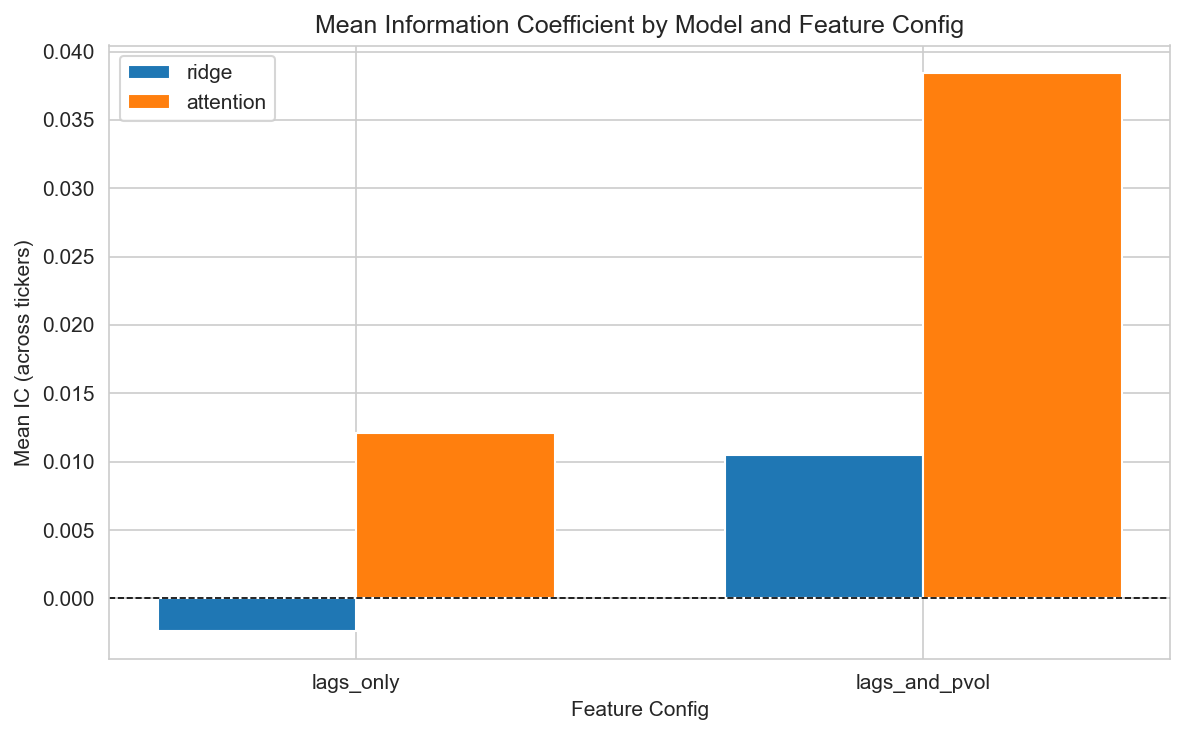

In [ ]:
summary_reset = summary.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(FEATURE_CONFIGS))
width = 0.35

for i, model_name in enumerate(MODELS.keys()):
    model_summary = summary_reset[summary_reset["model"] == model_name]
    ax.bar(x + i * width, model_summary["ic"], width, label=model_name)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(FEATURE_CONFIGS.keys()))
ax.set_xlabel("Feature Config")
ax.set_ylabel("Mean IC (across tickers)")
ax.set_title("Mean Information Coefficient by Model and Feature Config")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/01_mean_ic_summary.png", dpi=150, bbox_inches="tight")
plt.show()